In [1]:
from astropy.table import Table, vstack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from math import log10, floor
import CiCPlot

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from importlib import reload

In [2]:
#for paper
#Jan 2, 2026
sv3elgfiberassign= Table.read("datafiles/SV3_fiberassign_elg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_elg.csv")
sv3lrgfiberassign = Table.read("datafiles/SV3_fiberassign_lrg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_lrg.csv")

sv3elgfiberassign_ros = [sv3elgfiberassign[(sv3elgfiberassign['rosette'] == i)] for i in np.arange(1,21)]
sv3lrgfiberassign_ros = [sv3lrgfiberassign[(sv3lrgfiberassign['rosette'] == i)] for i in np.arange(1,21)]

sv3elgnofiberassign= Table.read("datafiles/SV3_nofiberassign_elg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_elg.csv")
sv3lrgnofiberassign = Table.read("datafiles/SV3_nofiberassign_lrg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_lrg.csv")

sv3elgnofiberassign_ros = [sv3elgnofiberassign[(sv3elgnofiberassign['rosette'] == i)] for i in np.arange(1,21)]
sv3lrgnofiberassign_ros = [sv3lrgnofiberassign[(sv3lrgnofiberassign['rosette'] == i)] for i in np.arange(1,21)]

'''sv3_mock_elg_complete = []
sv3_mock_elg_incomplete = []
sv3_mock_lrg_complete = []
sv3_mock_lrg_incomplete = []
for mocknumber in np.arange(25):
    sv3_mock_elg_complete.append(Table.read("datafiles/SV3_mock_complete_"+str(mocknumber)+"_elg.csv",format='csv'))
    sv3_mock_elg_incomplete.append(Table.read("datafiles/SV3_mock_incomplete_"+str(mocknumber)+"_elg.csv",format='csv'))
    sv3_mock_lrg_complete.append(Table.read("datafiles/SV3_mock_complete_"+str(mocknumber)+"_lrg.csv",format='csv'))
    sv3_mock_lrg_incomplete.append(Table.read("datafiles/SV3_mock_incomplete_"+str(mocknumber)+"_lrg.csv",format='csv'))
'''

'sv3_mock_elg_complete = []\nsv3_mock_elg_incomplete = []\nsv3_mock_lrg_complete = []\nsv3_mock_lrg_incomplete = []\nfor mocknumber in np.arange(25):\n    sv3_mock_elg_complete.append(Table.read("datafiles/SV3_mock_complete_"+str(mocknumber)+"_elg.csv",format=\'csv\'))\n    sv3_mock_elg_incomplete.append(Table.read("datafiles/SV3_mock_incomplete_"+str(mocknumber)+"_elg.csv",format=\'csv\'))\n    sv3_mock_lrg_complete.append(Table.read("datafiles/SV3_mock_complete_"+str(mocknumber)+"_lrg.csv",format=\'csv\'))\n    sv3_mock_lrg_incomplete.append(Table.read("datafiles/SV3_mock_incomplete_"+str(mocknumber)+"_lrg.csv",format=\'csv\'))\n'

In [3]:
Abacus_elg_complete = []
Abacus_elg_incomplete = []
Abacus_lrg_complete = []
Abacus_lrg_incomplete = []
for mocknumber in np.arange(18):
    Abacus_elg_complete.append(Table.read("datafiles/Abacus_complete_cleaned_"+str(mocknumber)+"_R1L40_elg.csv"))
    Abacus_elg_incomplete.append(Table.read("datafiles/ffa_cleaned_"+str(mocknumber)+"_R1L40_elg.csv"))
    Abacus_lrg_complete.append(Table.read("datafiles/Abacus_complete_cleaned_"+str(mocknumber)+"_R1L40_lrg.csv"))
    Abacus_lrg_incomplete.append(Table.read("datafiles/ffa_cleaned_"+str(mocknumber)+"_R1L40_lrg.csv"))

In [14]:
reload(CiCPlot)

<module 'CiCPlot' from '/global/u1/c/crmiller/CiC/CiCPlot.py'>

In [15]:
#mock catalogs with and without fiber assignment, for purposes of estimating effect of fiber incompleteness on counts in cylinders
binmax = 6
histsv3complete = CiCPlot.bootstrapCiCError(sv3elgnofiberassign_ros,sv3lrgnofiberassign_ros,binmax)
histsv3incomplete = CiCPlot.bootstrapCiCError(sv3elgfiberassign_ros,sv3lrgfiberassign_ros,binmax)


binmax = 6
histabcomplete = CiCPlot.bootstrapCiCError(Abacus_elg_complete,Abacus_lrg_complete,binmax)
histabincomplete = CiCPlot.bootstrapCiCError(Abacus_elg_incomplete,Abacus_lrg_incomplete,binmax)

hist1counts:  28557
hist2counts:  28278
[6.73482717324286e-09, 2.3120003782090633e-09, 6.292927378522308e-08, 8.146119809203656e-08, 1.1869282895462525e-08, 1.202026889517684e-08, 2.039655727684983e-08, 2.6305700095107666e-08, 5.087779063186351e-08, 4.6431664307406846e-08, 6.6533828691803996e-12, 1.0046331422726673e-07, 8.621434663420831e-07, 4.957763991128296e-10, 3.58750456161532e-08, 5.3575268151597994e-08, 8.83757595644069e-09, 6.770160810987367e-08, 2.2565868614663447e-08, 1.1185209654833048e-07]
[3.6032895080131754e-09, 1.4568782934181612e-06, 6.7734644126856e-08, 2.994811786184423e-07, 1.1205452188921047e-06, 1.5347404789033976e-08, 2.1736925667831752e-08, 7.870311139762145e-07, 1.7583357929152345e-06, 1.4303759420334132e-07, 2.00373969448439e-07, 3.8120014482280356e-07, 4.3379287756098444e-08, 2.7768747080036416e-07, 9.40759243484262e-09, 2.2133710351838114e-07, 1.2734737382861714e-07, 3.908424971813294e-07, 4.356508016214085e-10, 4.0088430956805865e-06]
[9.779373368494427e-08,

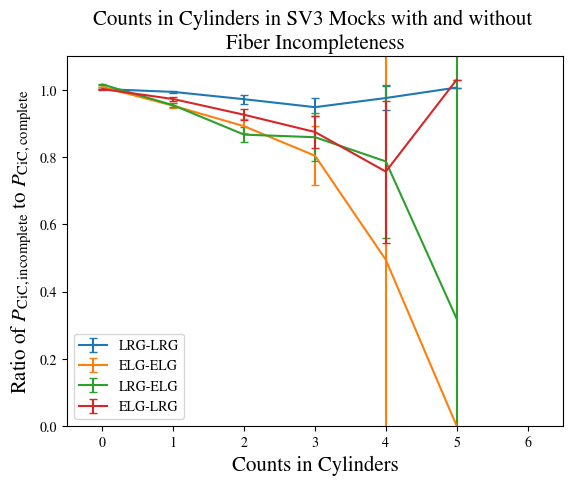

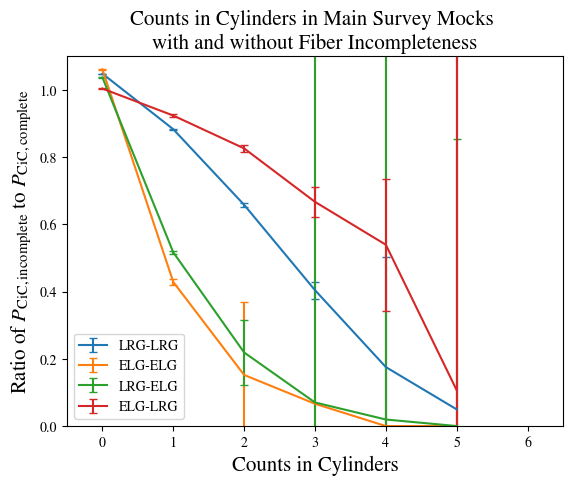

In [17]:
cat1 = histsv3complete
cat2 = histsv3incomplete
sv3ratios = CiCPlot.plotCiCRatio(cat1,cat2,title="Counts in Cylinders in SV3 Mocks with and without \nFiber Incompleteness",name='sv3inc')

cat1 = histabcomplete
cat2 = histabincomplete
abacusratios = CiCPlot.plotCiCRatio(cat1,cat2,title="Counts in Cylinders in Main Survey Mocks \nwith and without Fiber Incompleteness",name='abinc')

In [38]:
#for paper
sv3elg = Table.read("datafiles/SV3_zboundary_R1L40_elg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3_zboundary_R1L40_lrg.csv") #Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_lrg.csv")

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)] for i in np.arange(1,21)]

R_CiC = "1"
Abacus_elg = []
Abacus_lrg = []
for mocknumber in np.arange(18):
    Abacus_elg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R1L40_elg.csv",format='csv'))
    Abacus_lrg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R1L40_lrg.csv",format='csv'))

In [39]:
'''#for hole cleaning comparison

#cleaned
R_CiC = 1
Aurelio_cleaned_elg = []
Aurelio_cleaned_lrg = []
for mocknumber in np.arange(16):
    Aurelio_cleaned_elg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    Aurelio_cleaned_lrg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))


#with holes, not cleaned
Aurelio_holes_lrg = []
Aurelio_holes_elg = []
for mocknumber in np.arange(18):
    Aurelio_holes_elg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    Aurelio_holes_lrg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))

#no holes
Aurelio_noimmask_lrg = []
Aurelio_noimmask_elg = []
for mocknumber in np.arange(18):
    Aurelio_noimmask_elg.append(Table.read("datafiles/AurelioNoImmask"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    Aurelio_noimmask_lrg.append(Table.read("datafiles/AurelioNoImmask"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))'''

'#for hole cleaning comparison\n\n#cleaned\nR_CiC = 1\nAurelio_cleaned_elg = []\nAurelio_cleaned_lrg = []\nfor mocknumber in np.arange(16):\n    Aurelio_cleaned_elg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format=\'csv\'))\n    Aurelio_cleaned_lrg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format=\'csv\'))\n\n\n#with holes, not cleaned\nAurelio_holes_lrg = []\nAurelio_holes_elg = []\nfor mocknumber in np.arange(18):\n    Aurelio_holes_elg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format=\'csv\'))\n    Aurelio_holes_lrg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format=\'csv\'))\n\n#no holes\nAurelio_noimmask_lrg = []\nAurelio_noimmask_elg = []\nfor mocknumber in np.arange(18):\n    Aurelio_noimmask_elg.append(Table.read("datafiles/AurelioNoImmask"+str(mocknumber)+"_R"+str(R_CiC)+"

## For Paper ##

In [40]:
binmax = 6
cat1 = [sv3elg_ros,sv3lrg_ros]
cat2 = [Abacus_elg,Abacus_lrg]
#cat3 = [randoms_elg,randoms_lrg]

#cat4 = [randoms_sv3_elg,randoms_sv3_lrg]
#cat5 = [randoms_elg,randoms_lrg]

In [41]:
cichist = CiCPlot.bootstrapCiCError(*cat1,6,weights=sv3ratios)

In [42]:
tag = "weighted"

/tmp/ipykernel_2340812/1859505494.py:88: RuntimeWarning: divide by zero encountered in log
  hist1 = np.log(cichist.elgbivariate)
/tmp/ipykernel_2340812/1859505494.py:107: RuntimeWarning: divide by zero encountered in log
  hist1 = np.log(cichist.lrgbivariate)


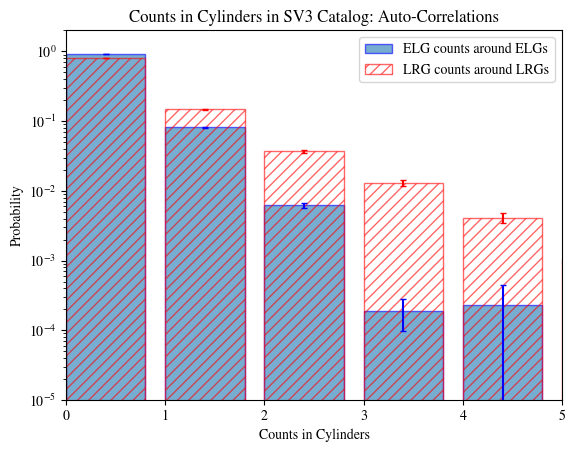

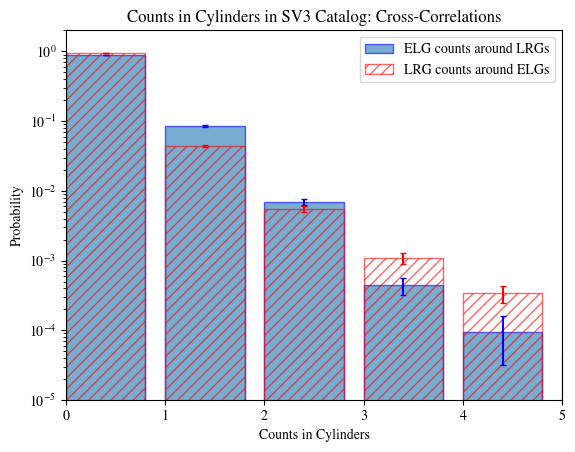

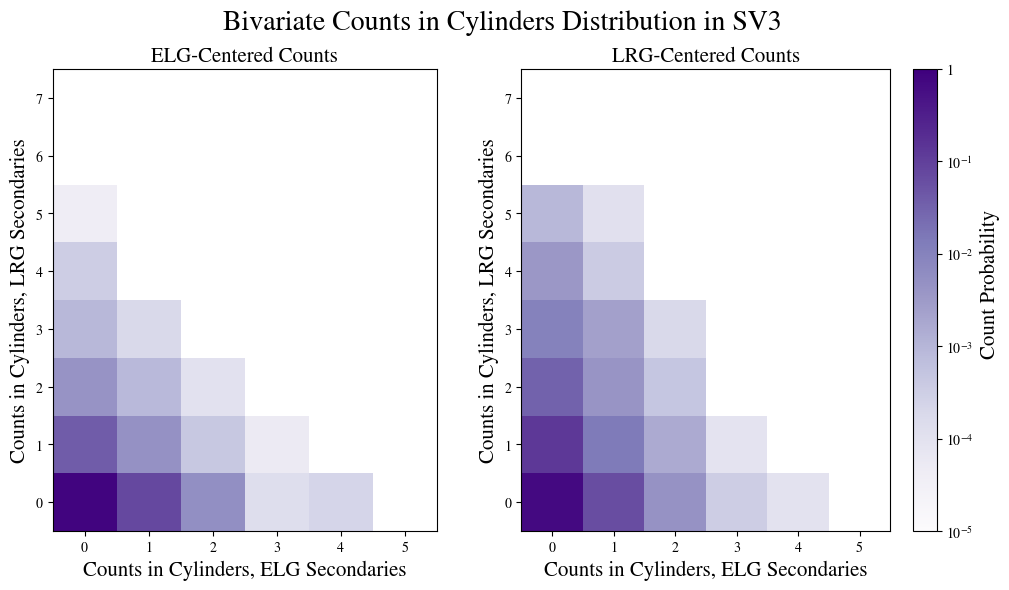

In [43]:
np.errstate(divide='ignore', invalid='ignore')
fontsize = 15
titlesize = 20
matplotlib.fontsize=15
maxcounts=7
bins=np.arange(binmax+1)
plt.figure()
plt.xlabel("Counts in Cylinders")
plt.ylabel("Probability")
plt.bar(bins[:-1],cichist.elghistcomb,label = "ELG counts around ELGs",alpha=0.6, yerr = cichist.elg_CiCerr,align='edge',
                edgecolor='blue',ecolor='blue',capsize=2)
plt.title("Counts in Cylinders in SV3 Catalog: Auto-Correlations")
plt.bar(bins[:-1], cichist.lrghistcomb, label='LRG counts around LRGs',alpha=0.6, yerr = cichist.lrg_CiCerr,align='edge',
                edgecolor='red',ecolor='red',capsize=2,hatch='///',color='none')

plt.savefig("forpaper/"+tag+"univariateauto.png")

plt.legend()
plt.yscale("log")
plt.xlim(0,5)
plt.ylim(1e-5,2)
plt.figure()
plt.xlabel("Counts in Cylinders")
plt.ylabel("Probability")
plt.bar(bins[:-1],cichist.lrgelghistcomb,label='ELG counts around LRGs',alpha=0.6, yerr = cichist.lrgelg_CiCerr,align='edge',
                edgecolor='blue',ecolor='blue',capsize=2)
plt.bar(bins[:-1],cichist.elglrghistcomb,label='LRG counts around ELGs',alpha=0.6, yerr = cichist.elglrg_CiCerr,align='edge',
                edgecolor='red',ecolor='red',capsize=2,hatch='///',color='none')
plt.yscale("log")
plt.xlim(0,5)
plt.ylim(1e-5,2)
plt.title("Counts in Cylinders in SV3 Catalog: Cross-Correlations")
plt.legend()
plt.savefig("forpaper/"+tag+"univariatecross.png")
'''
ax[1,index].errorbar(bins[:-1]+0.5,cichist.elghistcomb,yerr=ratio_err,color='black',capsize=2)
plt.legend()
def getHist(catalog):
            match tracers:
                case ["ELG","ELG"]:
                    hist = catalog.elghistcomb
                    err = catalog.elg_CiCerr
                case ["LRG","LRG"]:
                    hist = catalog.lrghistcomb
                    err = catalog.lrg_CiCerr
                case ["ELG","LRG"]:
                    hist = catalog.elglrghistcomb
                    err = catalog.elglrg_CiCerr
                case ["LRG","ELG"]:
                    hist = catalog.lrgelghistcomb
                    err = catalog.lrgelg_CiCerr
            return hist, err
        hist1, err1 = getHist(catalog1)
        hist2, err2 = getHist(catalog2)
        #fig,ax = plt.subplots(2,gridspec_kw={'height_ratios': [2, 1]},figsize=(7,7))
        ax[1,index].set_xlabel("Counts in Cylinders",fontsize=fontsize)
        ax[0,index].set_title(tracers[0]+" Counts Around "+tracers[1]+"s",fontsize=fontsize)
        ax[0,index].tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False)
        ax[1,index].set_xticks(np.arange(xrange + 1))
        ax[0,index].set_xlim(-0.5,xrange + 0.5)
        ax[0,index].set_ylim(1e-6,1.5)
        ax[1,index].set_xlim(-0.5,xrange + 0.5)
        ax[0,index].bar(bins[:-1], hist1, label=name1,alpha=0.6, yerr = err1,align='edge',
                edgecolor='blue',ecolor='blue',capsize=2)
        ax[0,index].bar(bins[:-1], hist2, label=name2,alpha=0.6, yerr = err2,align='edge',
                edgecolor='orange',ecolor='red',capsize=2)
        ax[0,index].set_yscale("log")
    
        #ratio of 2 catalogs
        ratio = hist1/hist2
        ratio_err = np.sqrt((err1/hist2)**2 + (hist1/hist2**2*err2)**2)
        ax[1,index].errorbar(bins[:-1]+0.5,ratio,yerr=ratio_err,color='black',capsize=2)
        ax[1,index].plot([-0.5,xrange+0.5],[1,1],color='black',linestyle='dotted')
        #ax[1].set_ylim(0,2)
        ax[1,index].set_ylim(0,2)
        plt.subplots_adjust(hspace=0.04)
        ax[0,index].legend()'''


binsx = bins-0.5
binsy = bins-0.5
#ELG bivariate distribution
hist1 = np.log(cichist.elgbivariate)
fig, ax = plt.subplots(1,2,figsize=(12,6),gridspec_kw={'width_ratios': [1, 1.2]})
plt.suptitle("Bivariate Counts in Cylinders Distribution in SV3",fontsize=20)
#plt.tight_layout()
pc = ax[0].pcolormesh(binsx,binsy,hist1,vmax=np.log(1),vmin=np.log(10**(-5)),cmap='Purples')
#cbar = plt.colorbar(pc,ticks = np.log([1/8,1/4,1/2,1,2,4,8]))
#cbar.ax.set_yticklabels(['1/8','1/4',"1/2","1",'2','4','8'])
ax[0].set_title("ELG-Centered Counts",fontsize=fontsize)
ax[0].set_xlabel("Counts in Cylinders, ELG Secondaries",fontsize=fontsize)
ax[0].set_ylabel("Counts in Cylinders, LRG Secondaries",fontsize=fontsize)
ax[0].set_xlim(-0.5,maxcounts+0.5)
ax[0].set_ylim(-0.5,maxcounts+0.5)
ax[0].set_xticks(np.arange(0,6),labels=[str(i) for i in np.arange(0,6)])

ax[0].set_xlim(-0.5,5.5)
ax[0].set_ylim(-0.5,7.5)


#ELG bivariate distribution
hist1 = np.log(cichist.lrgbivariate)
#fig, ax = plt.subplots(1,2,figsize=(12,5),gridspec_kw={'width_ratios': [1, 1.2]})
plt.suptitle("Bivariate Counts in Cylinders Distribution in SV3",fontsize=20)
#plt.tight_layout()
pc = ax[1].pcolormesh(binsx,binsy,hist1,vmax=np.log(1),vmin=np.log(10**(-5)),cmap='Purples')
#cbar = plt.colorbar(pc,ticks = np.log([1/8,1/4,1/2,1,2,4,8]))
#cbar.ax.set_yticklabels(['1/8','1/4',"1/2","1",'2','4','8'])
ax[1].set_title("LRG-Centered Counts",fontsize=fontsize)
ax[1].set_xlabel("Counts in Cylinders, ELG Secondaries",fontsize=fontsize)
ax[1].set_ylabel("Counts in Cylinders, LRG Secondaries",fontsize=fontsize)
ax[1].set_xlim(-0.5,maxcounts+0.5)
ax[1].set_ylim(-0.5,maxcounts+0.5)
ax[1].set_xticks(np.arange(0,6),labels=[str(i) for i in np.arange(0,6)])

ax[1].set_xlim(-0.5,5.5)
ax[1].set_ylim(-0.5,7.5)
#plt.savefig("forpaper/SV3bivariate"+figtag+".png")

cbar = plt.colorbar(pc,ticks = np.log([1,0.1,1e-2,1e-3,1e-4,1e-5]))
cbar.ax.set_yticklabels(['1',r"$10^{-1}$",r"$10^{-2}$",r"$10^{-3}$",r"$10^{-4}$",r"$10^{-5}$"])
ax[1].text(7.2, 2.5, "Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True,fontsize=fontsize)
plt.savefig("forpaper/" + tag + "Abacus_elgSV3bivariate.png")

In [44]:
'''binmax = 15
cleaned = bootstrapCiCError(Aurelio_cleaned_elg, Aurelio_cleaned_lrg, binmax)
holes = bootstrapCiCError(Aurelio_holes_elg, Aurelio_holes_lrg, binmax)
noholes = bootstrapCiCError(Aurelio_noimmask_elg, Aurelio_noimmask_lrg, binmax)'''

'binmax = 15\ncleaned = bootstrapCiCError(Aurelio_cleaned_elg, Aurelio_cleaned_lrg, binmax)\nholes = bootstrapCiCError(Aurelio_holes_elg, Aurelio_holes_lrg, binmax)\nnoholes = bootstrapCiCError(Aurelio_noimmask_elg, Aurelio_noimmask_lrg, binmax)'

In [45]:
'''cat1 = histsv3complete
cat2 = histsv3incomplete
plotCiCRatio(cat1,cat2,name="",title="Counts in Cylinders in SV3 Mocks with and without Fiber Incompleteness")'''

'cat1 = histsv3complete\ncat2 = histsv3incomplete\nplotCiCRatio(cat1,cat2,name="",title="Counts in Cylinders in SV3 Mocks with and without Fiber Incompleteness")'

NameError: name 'holes' is not defined

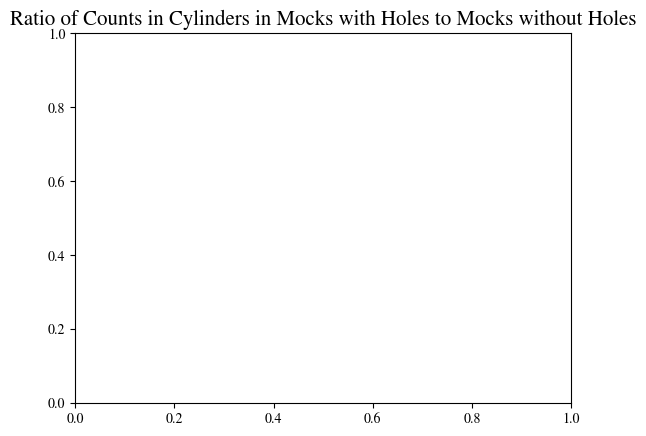

In [46]:
'''
        self.elghistcomb = elghistsum/ntables
        self.lrghistcomb = lrghistsum/ntables
        self.elglrghistcomb = elglrghistsum/ntables
        self.lrgelghistcomb = lrgelghistsum/ntables
        self.elgbivariate = elgbivariatesum/ntables
        self.lrgbivariate = lrgbivariatesum/ntables
'''
titlesize=20
textsize=15
plt.figure()
plt.title("Ratio of Counts in Cylinders in Mocks with Holes to Mocks without Holes",fontsize=textsize)
#LRGS
holeratio = holes.lrghistcomb/noholes.lrghistcomb
cleanratio  = cleaned.lrghistcomb/noholes.lrghistcomb
yerrhole = np.sqrt((holes.lrg_CiCerr/noholes.lrghistcomb)**2+(noholes.lrg_CiCerr/noholes.lrghistcomb**2*noholes.lrghistcomb)**2)
yerrclean = np.sqrt((cleaned.lrg_CiCerr/noholes.lrghistcomb)**2+(noholes.lrg_CiCerr/cleaned.lrghistcomb**2*noholes.lrghistcomb)**2)
plt.errorbar(np.arange(0,maxCiC+1),holeratio[:maxCiC+1],yerr = yerrhole[:maxCiC+1],label = "LRGs, with Holes",capsize=3,
            color='red',linestyle='--')
plt.errorbar(np.arange(0,maxCiC+1),cleanratio[:maxCiC+1],yerr = yerrhole[:maxCiC+1],label = "LRGs, after Hole Cleaning",
            capsize=3,color='red')
plt.plot([0,maxCiC],np.repeat(1,2),linestyle="dotted",color = "gray")
plt.xlim(-0.5,maxCiC+0.5)
plt.xlabel("Counts in Cylinders",fontsize=textsize)
plt.ylabel(r"Probability Ratio $P_\mathrm{holes}(N)/P_\mathrm{no holes}(N)$",fontsize=textsize)


#ELGs
holeratio = holes.elghistcomb/noholes.elghistcomb
cleanratio  = cleaned.elghistcomb/noholes.elghistcomb
yerrhole = np.sqrt((holes.elg_CiCerr/noholes.elghistcomb)**2+(noholes.elg_CiCerr/noholes.elghistcomb**2*noholes.elghistcomb)**2)
yerrclean = np.sqrt((cleaned.elg_CiCerr/noholes.elghistcomb)**2+(noholes.elg_CiCerr/cleaned.elghistcomb**2*noholes.elghistcomb)**2)
plt.errorbar(np.arange(0,binmax),holeratio,yerr = yerrhole,label = "ELGs, with Holes",capsize=3,color='blue',linestyle='--')
plt.errorbar(np.arange(0,binmax),cleanratio,yerr = yerrhole,label = "ELGs, after Hole Cleaning",capsize=3,color='blue')
plt.plot([-.5,6.5],np.repeat(1,2),color = "gray")
plt.legend()
plt.ylim(0.8,1.2)
plt.savefig("forpaper/holecleaning.png",dpi=300)

'''
#ELG-LRG
maxCiC = 6
plt.figure()
holeratio = holes.elglrghistcomb/noholes.elglrghistcomb
cleanratio  = cleaned.elglrghistcomb/noholes.elglrghistcomb
yerrhole = np.sqrt((holes.elglrg_CiCerr/holes.elglrghistcomb)**2+(noholes.elglrg_CiCerr/noholes.elglrghistcomb)**2)*holeratio
yerrclean = np.sqrt((cleaned.elglrg_CiCerr/cleaned.elglrghistcomb)**2+(noholes.elglrg_CiCerr/noholes.elglrghistcomb)**2)*cleanratio
plt.errorbar(np.arange(0,maxCiC+1),holeratio[:maxCiC+1],yerr = yerrhole[:maxCiC+1],label = "Mock Catalog with Holes")
plt.errorbar(np.arange(0,maxCiC+1),cleanratio[:maxCiC+1],yerr = yerrhole[:maxCiC+1],label = "Mock Catalog after Hole Cleaning")
plt.plot([0,maxCiC],np.repeat(1,2),linestyle="dotted",color = "gray")
plt.title("Ratio of ELG-LRG Counts in Cylinders in Mocks with Holes to Mocks without Holes")
plt.legend()
plt.xlim(-0.5,maxCiC+0.5)
plt.xlabel("Counts in Cylinders")
plt.ylabel(r"Probability Ratio $P_\mathrm{holes}(N)/P_\mathrm{no holes}(N)$")
plt.ylim(0.6,1.2)
'''
#LRG-ELG

In [47]:
reload(CiCPlot)

<module 'CiCPlot' from '/global/u1/c/crmiller/CiC/CiCPlot.py'>

In [48]:
correctionratios = Table(sv3ratios, names = ['elgelg','lrglrg','elglrg','lrgelg'])
correctionratios.write("datafiles/SV3_CiC_correction_ratios.csv",format='csv',overwrite=True)

/global/u1/c/crmiller/CiC/CiCPlot.py:46: RuntimeWarning: invalid value encountered in multiply
  density = True)[0]*elgweights for i in range(ntables)])
/global/u1/c/crmiller/CiC/CiCPlot.py:56: RuntimeWarning: invalid value encountered in multiply
  density = False)[0]*elgweights for i in range(ntables)])
/global/u1/c/crmiller/CiC/CiCPlot.py:76: RuntimeWarning: invalid value encountered in multiply
  density=True,bins=bins)[0]*multitracerweights_elg for i in range(ntables)])
/global/u1/c/crmiller/CiC/CiCPlot.py:186: RuntimeWarning: divide by zero encountered in true_divide
  ratio_unweighted_err = np.sqrt((err_unweighted1/hist_unweighted2)**2 + (hist_unweighted1/hist_unweighted2**2*err_unweighted2)**2)
/global/u1/c/crmiller/CiC/CiCPlot.py:187: RuntimeWarning: divide by zero encountered in true_divide
  ax[1,index].errorbar(bins[:-1]+0.5,ratio_unweighted,yerr=ratio_unweighted_err,color='gray',capsize=2,label='Unweighted')
/global/u1/c/crmiller/CiC/CiCPlot.py:187: RuntimeWarning: invalid

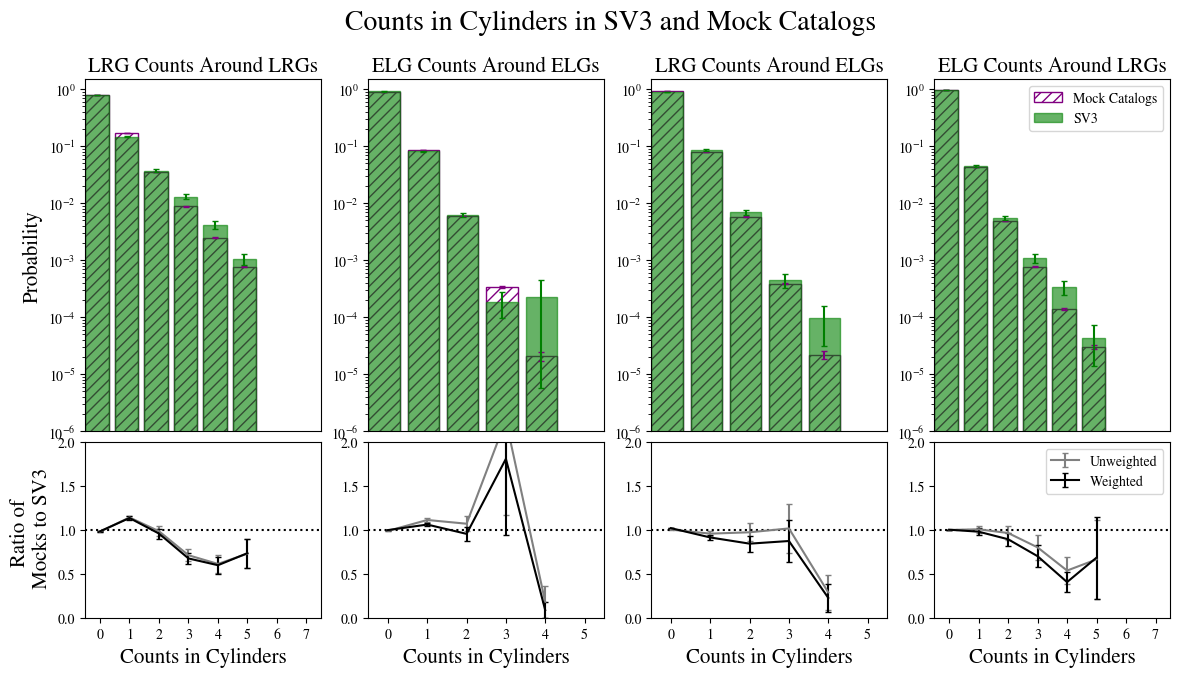

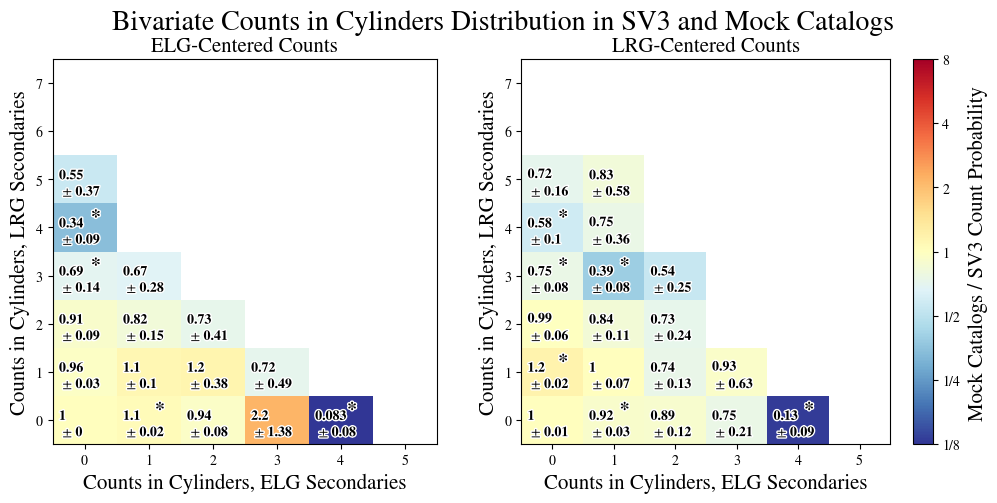

In [ ]:
name1 = "SV3"
name2 = "Mock Catalogs"
figtag = "SV3AbacusNadj_weighted"
figdir = "forpaper/"
CiCPlot.compare2CatalogsCiC(cat2, cat1, name2, name1, binmax, figdir, figtag,weights=[None,sv3ratios],plot_unweighted=True,staroffset=0.15)

In [ ]:
sv3counts = bootstrapCiCError(*cat1,25)

for j in range(25):
    for i in range(25):
        countprob = sv3counts.elgbivariate[i][j]
        err = sv3counts.elgmultitracer_CiCerr[i][j]
        if countprob != 0:
            print("LRG: ",i,", ELG: ",j,)
            print(countprob, err)

print("\n\n\n")
for j in range(25):
    for i in range(25):
        countprob = sv3counts.lrgbivariate[i][j]
        err = sv3counts.lrgmultitracer_CiCerr[i][j]
        if countprob != 0:
            print("LRG: ",i,", ELG: ",j,)
            print(countprob, err)

20
LRG:  0 , ELG:  0
0.8726394714729006 0.002244915731679211
LRG:  1 , ELG:  0
0.038239849112425076 0.0012749485974237983
LRG:  2 , ELG:  0
0.004233711698832665 0.0003974460813866971
LRG:  3 , ELG:  0
0.0008004348704878482 0.00016167521041590813
LRG:  4 , ELG:  0
0.000257798577228488 7.060586328316847e-05
LRG:  5 , ELG:  0
4.478811599373745e-05 3.013214570163799e-05
LRG:  0 , ELG:  1
0.07259209941253024 0.0014740876198764197
LRG:  1 , ELG:  1
0.004454477021977629 0.00039733248134065014
LRG:  2 , ELG:  1
0.0007839319943583531 0.00014459531425615682
LRG:  3 , ELG:  1
0.00015709199345200452 6.62979377584154e-05
LRG:  0 , ELG:  2
0.0050495025876968564 0.0004362310519188894
LRG:  1 , ELG:  2
0.0003932368431390851 0.00012785565793348408
LRG:  2 , ELG:  2
8.94131299834633e-05 5.004371370148079e-05
LRG:  0 , ELG:  3
0.00010895165783081923 6.94062524540953e-05
LRG:  1 , ELG:  3
4.201687348207424e-05 2.8185800472120797e-05
LRG:  0 , ELG:  4
0.00011322463768115942 0.00011035772582437684




LRG: 

In [ ]:
name1 = "SV3"
name2 = "Abacus Mock Catalogs"
figtag = "countsaroundrandoms"
figdir = "forpaper/"
cat4[0][0]['N_CiC'] = cat4[0][0]['N_elgCiC']
cat4[1][0]['N_CiC'] = cat4[1][0]['N_lrgCiC']
cat5[0][0]['N_CiC'] = cat5[0][0]['N_elgCiC']
cat5[1][0]['N_CiC'] = cat5[1][0]['N_lrgCiC']
compare2CatalogsCiC(cat4, cat5, name2, name1, binmax, figdir, figtag)

In [ ]:
#SV3
print("SV3 moments")
sv3elgmom,sv3lrgmom = makeMomentTable(*cat1,3,momentSimple)
#Abacus
print("Abacus moments")
abacuselgmom,abacuslrgmom = makeMomentTable(*cat2,3,momentSimple)

SV3 moments
Moments of ELG-centered bivariate counts in cylinders distribution
ELG Order, LRG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 5.7200e-02     2.0000e-03
              0 .. 2 7.6900e-02     3.2000e-03
              0 .. 3 1.3100e-01     8.5000e-03
              1 .. 0 8.9600e-02     1.8000e-03
              1 .. 1 7.3000e-03     8.0000e-04
              1 .. 2 1.0000e-02     1.3000e-03
              2 .. 0 1.0270e-01     2.7000e-03
              2 .. 1 8.6000e-03     1.1000e-03
              3 .. 0 1.3200e-01     7.7000e-03
Moments of LRG-centered bivariate counts in cylinders distribution
LRG Order, ELG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 9.4000e-02     3.4000e-03
              0 .. 2 1.0810e-01     5.0000e-03
              0 .. 3 1.3920e-01     9.1000e-03
              1 .. 0 2.7630e-01     9.0000e-03
              1 .. 1 3.5900e-02     2.9000e-03
        

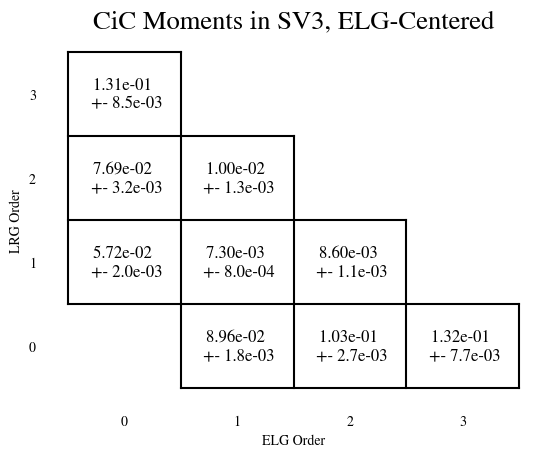

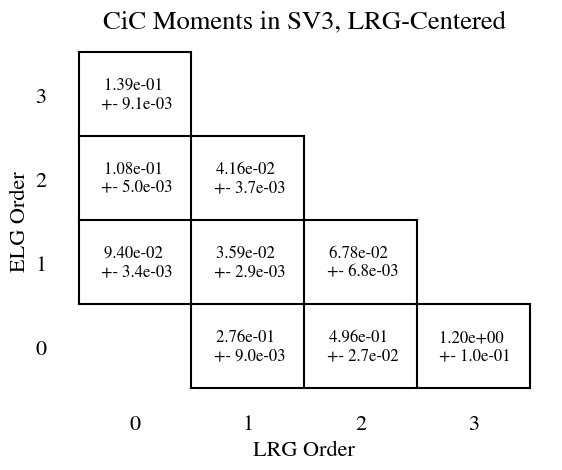

In [ ]:
showMomentTable(sv3elgmom,title="CiC Moments in SV3, ELG-Centered")
showMomentTable(sv3lrgmom,title="CiC Moments in SV3, LRG-Centered",lrg=True)

In [ ]:
elgcomp = Table()
elgcomp["ELG Order, LRG Order"] = abacuselgmom["ELG Order, LRG Order"]
elgcomp["Moment"] = abacuselgmom["Moment"]/sv3elgmom["Moment"]
elgcomp["Standard Error"] = np.sqrt((abacuselgmom["Standard Error"]/abacuselgmom["Moment"])**2 \
                           + (sv3elgmom["Standard Error"]/sv3elgmom["Moment"])**2)

lrgcomp = Table()
lrgcomp["LRG Order, ELG Order"] = abacuslrgmom["LRG Order, ELG Order"]
lrgcomp["Moment"] = abacuslrgmom["Moment"]/sv3lrgmom["Moment"]
lrgcomp["Standard Error"] = np.sqrt((abacuslrgmom["Standard Error"]/abacuslrgmom["Moment"])**2 \
                           + (sv3lrgmom["Standard Error"]/sv3lrgmom["Moment"])**2)

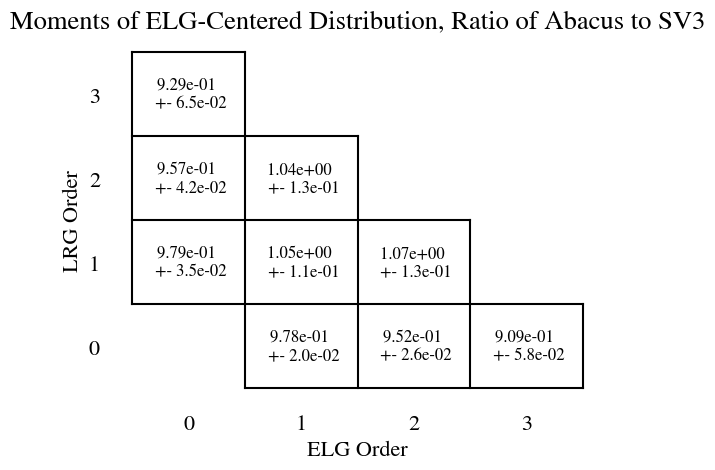

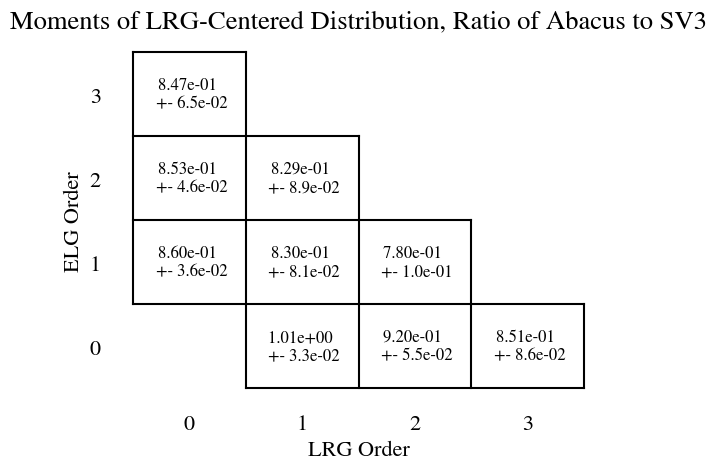

In [ ]:
showMomentTable(elgcomp,title="Moments of ELG-Centered Distribution, Ratio of Abacus to SV3")
showMomentTable(lrgcomp,title="Moments of LRG-Centered Distribution, Ratio of Abacus to SV3",lrg=True)

In [ ]:
#SV3
print("SV3 moments")
sv3elgmom,sv3lrgmom = makeMomentTable(*cat1,3,factorialMoment)
#Abacus
print("Abacus moments")
abacuselgmom,abacuslrgmom = makeMomentTable(*cat2,3,factorialMoment)

elgcomp = Table()
elgcomp["ELG Order, LRG Order"] = abacuselgmom["ELG Order, LRG Order"]
elgcomp["Moment"] = abacuselgmom["Moment"]/sv3elgmom["Moment"]
elgcomp["Standard Error"] = np.sqrt((abacuselgmom["Standard Error"]/abacuselgmom["Moment"])**2 \
                           + (sv3elgmom["Standard Error"]/sv3elgmom["Moment"])**2)

lrgcomp = Table()
lrgcomp["LRG Order, ELG Order"] = abacuslrgmom["LRG Order, ELG Order"]
lrgcomp["Moment"] = abacuslrgmom["Moment"]/sv3lrgmom["Moment"]
lrgcomp["Standard Error"] = np.sqrt((abacuslrgmom["Standard Error"]/abacuslrgmom["Moment"])**2 \
                           + (sv3lrgmom["Standard Error"]/sv3lrgmom["Moment"])**2)

SV3 moments
Moments of ELG-centered bivariate counts in cylinders distribution
ELG Order, LRG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 5.7200e-02     2.0000e-03
              0 .. 2 1.9700e-02     1.7000e-03
              0 .. 3 1.4600e-02     2.6000e-03
              1 .. 0 8.9600e-02     1.8000e-03
              1 .. 1 7.3000e-03     8.0000e-04
              1 .. 2 2.6000e-03     6.0000e-04
              2 .. 0 1.3100e-02     1.7000e-03
              2 .. 1 1.2000e-03     4.0000e-04
              3 .. 0 3.1000e-03     2.6000e-03
Moments of LRG-centered bivariate counts in cylinders distribution
LRG Order, ELG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 9.4000e-02     3.4000e-03
              0 .. 2 1.4000e-02     1.8000e-03
              0 .. 3 3.1000e-03     1.1000e-03
              1 .. 0 2.7630e-01     9.0000e-03
              1 .. 1 3.5900e-02     2.9000e-03
        

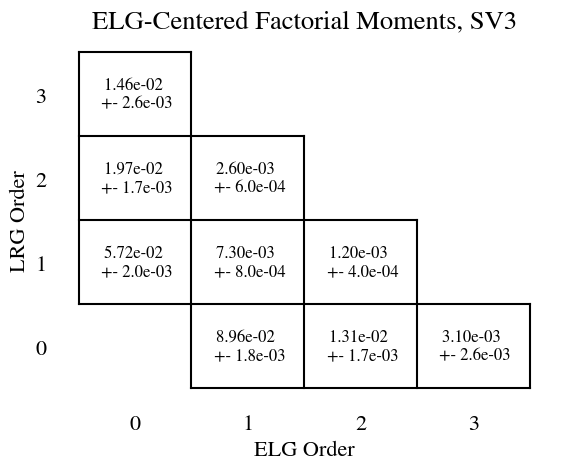

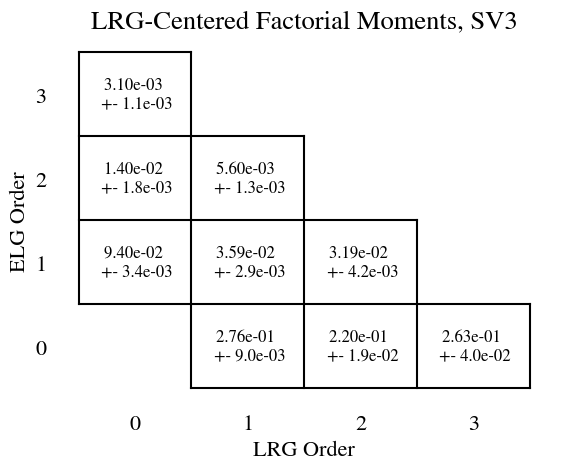

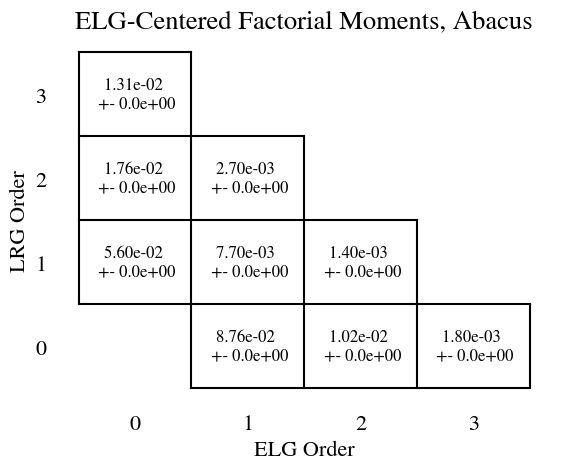

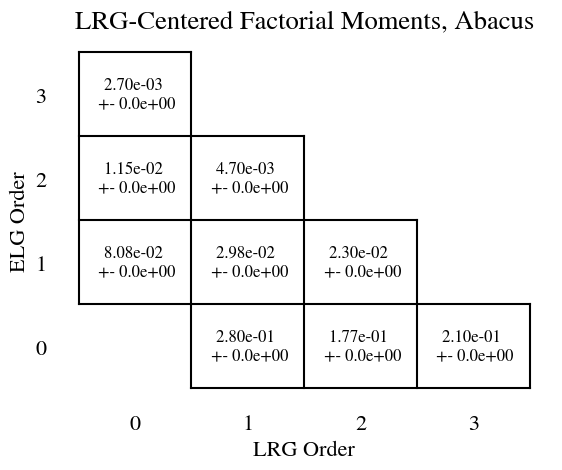

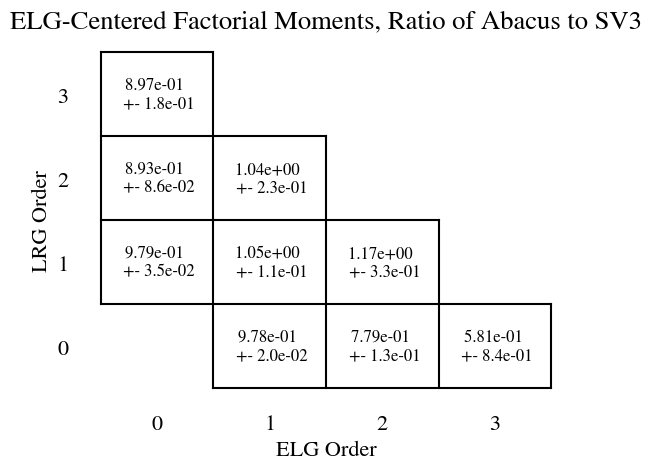

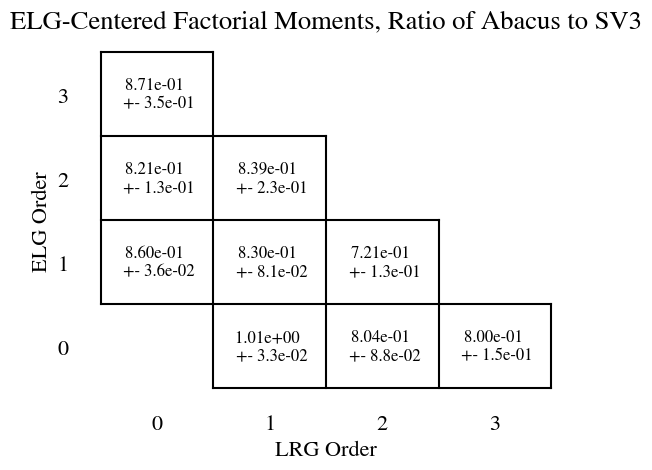

In [ ]:
showMomentTable(sv3elgmom,title="ELG-Centered Factorial Moments, SV3")
showMomentTable(sv3lrgmom,title="LRG-Centered Factorial Moments, SV3",lrg=True)

showMomentTable(abacuselgmom,title="ELG-Centered Factorial Moments, Abacus")
showMomentTable(abacuslrgmom,title="LRG-Centered Factorial Moments, Abacus",lrg=True)

showMomentTable(elgcomp,title='ELG-Centered Factorial Moments, Ratio of Abacus to SV3')
showMomentTable(lrgcomp,title='ELG-Centered Factorial Moments, Ratio of Abacus to SV3',lrg=True)

In [ ]:
#SV3
V_cyl = 1*40*np.pi*cosmo.h**3
#elgtables, lrgtables, maxorder, V_cyl, nzelg, nzlrg
print("SV3 moments")
nzelg = nzsv3
nzlrg = nzsv3lrg
sv3elgmom,sv3lrgmom = makeMomentTablenZ(*cat1,3,V_cyl,nzelg,nzlrg)
#Abacus
print("Abacus moments")
nzelg = nzabacusadj_elg
nzlrg = nzabacusadj_lrg
abacuselgmom,abacuslrgmom = makeMomentTablenZ(*[cat2[0][:1],cat2[1][:1]],3,V_cyl,nzelg,nzlrg,zname='RSDZ')

elgcomp = Table()
elgcomp["ELG Order, LRG Order"] = abacuselgmom["ELG Order, LRG Order"]
elgcomp["Moment"] = abacuselgmom["Moment"]/sv3elgmom["Moment"]
elgcomp["Standard Error"] = np.sqrt((abacuselgmom["Standard Error"]/abacuselgmom["Moment"])**2 \
                           + (sv3elgmom["Standard Error"]/sv3elgmom["Moment"])**2)

lrgcomp = Table()
lrgcomp["LRG Order, ELG Order"] = abacuslrgmom["LRG Order, ELG Order"]
lrgcomp["Moment"] = abacuslrgmom["Moment"]/sv3lrgmom["Moment"]
lrgcomp["Standard Error"] = np.sqrt((abacuslrgmom["Standard Error"]/abacuslrgmom["Moment"])**2 \
                           + (sv3lrgmom["Standard Error"]/sv3lrgmom["Moment"])**2)
'''
print("Moments of ELG-Centered Distribution, Ratio of Abacus to SV3")
print(elgcomp)
print("Moments of LRG-Centered Distribution, Ratio of Abacus to SV3")
print(lrgcomp)
'''

SV3 moments
Moments of ELG-centered bivariate counts in cylinders distribution
ELG Order, LRG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 4.3600e-02     1.9000e-03
              0 .. 2 1.8200e-02     1.6000e-03
              0 .. 3 1.3700e-02     2.5000e-03
              1 .. 0 6.6400e-02     1.8000e-03
              1 .. 1 5.2000e-03     8.0000e-04
              1 .. 2 2.0000e-03     6.0000e-04
              2 .. 0 9.4000e-03     1.7000e-03
              2 .. 1 8.0000e-04     3.0000e-04
              3 .. 0 2.3000e-03     2.5000e-03
Moments of LRG-centered bivariate counts in cylinders distribution
LRG Order, ELG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 7.1600e-02     3.4000e-03
              0 .. 2 1.0300e-02     1.7000e-03
              0 .. 3 2.3000e-03     1.0000e-03
              1 .. 0 2.6130e-01     9.0000e-03
              1 .. 1 2.8800e-02     2.8000e-03
        

'\nprint("Moments of ELG-Centered Distribution, Ratio of Abacus to SV3")\nprint(elgcomp)\nprint("Moments of LRG-Centered Distribution, Ratio of Abacus to SV3")\nprint(lrgcomp)\n'

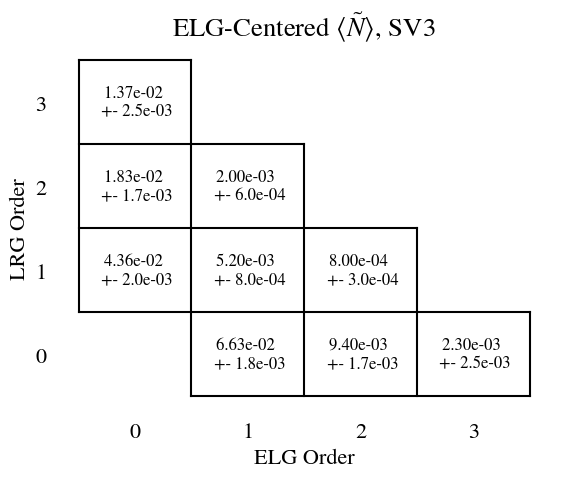

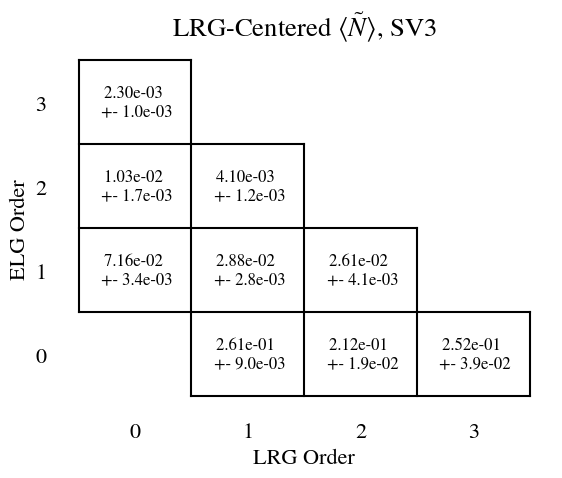

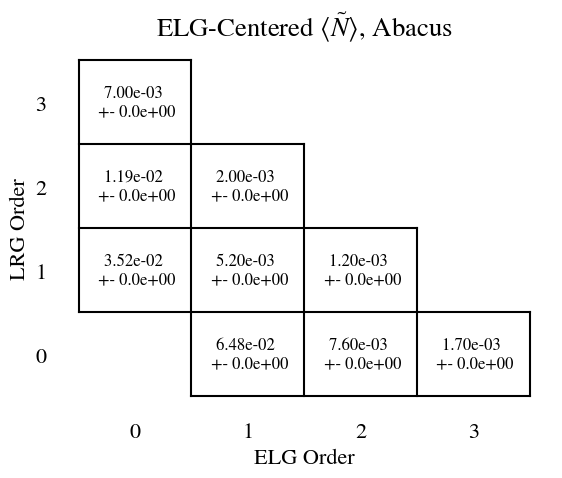

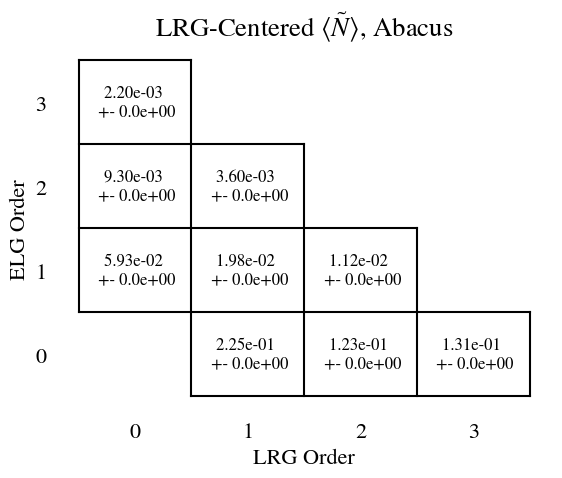

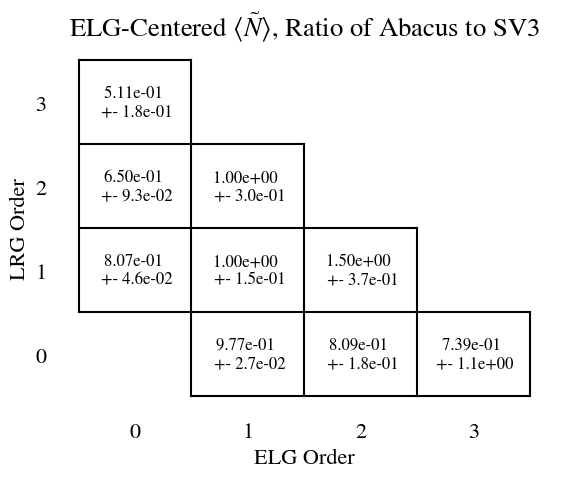

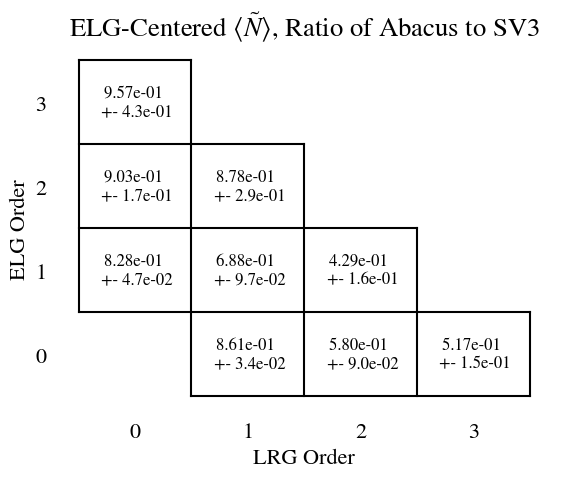

In [ ]:
showMomentTable(sv3elgmom,title=r"ELG-Centered $\left<\tilde{N}\right>$, SV3")
showMomentTable(sv3lrgmom,title=r"LRG-Centered $\left<\tilde{N}\right>$, SV3",lrg=True)

showMomentTable(abacuselgmom,title=r"ELG-Centered $\left<\tilde{N}\right>$, Abacus")
showMomentTable(abacuslrgmom,title=r"LRG-Centered $\left<\tilde{N}\right>$, Abacus",lrg=True)

showMomentTable(elgcomp,title=r'ELG-Centered $\left<\tilde{N}\right>$, Ratio of Abacus to SV3')
showMomentTable(lrgcomp,title=r'ELG-Centered $\left<\tilde{N}\right>$, Ratio of Abacus to SV3',lrg=True)

In [ ]:

'''
nzelg = nzsv3
nzlrg = nzsv3lrg
nzelg = nzabacusadj_elg
nzlrg = nzabacusadj_lrg
zlim = [0.75695,0.9919]
nbins=20
redshift = np.linspace(zlim,nbins)

nz1 = nzelg
nz2 = nzlrg
showMomentTableXiBar(sv3elgmom,nz1,nz2,redshift,V_cyl,lrg=False,title=r"ELG-Centered $\bar{\xi}$, SV3")
showMomentTableXiBar(sv3lrgmom,title=r"LRG-Centered $\left<\tilde{N}\right>$, SV3",lrg=True)

showMomentTableXiBar(abacuselgmom,title=r"ELG-Centered $\left<\tilde{N}\right>$, Abacus")
showMomentTable(abacuslrgmom,title=r"LRG-Centered $\left<\tilde{N}\right>$, Abacus",lrg=True)

showMomentTableXiBar(elgcomp,title=r'ELG-Centered $\left<\tilde{N}\right>$, Ratio of Abacus to SV3')
showMomentTableXiBar(lrgcomp,title=r'ELG-Centered $\left<\tilde{N}\right>$, Ratio of Abacus to SV3',lrg=True)


#showMomentTableXiBar(table,nz1,nz2,Vcyl,lrg = False,,title=""):'''

TypeError: showMomentTableXiBar() got multiple values for argument 'lrg'

In [ ]:
print("SV3")
nzelg = nzsv3
nzlrg = nzsv3lrg
sv3randomelgmom,sv3randomlrgmom = makeMomentTablenZ(cat4[0][:100000],cat4[1][:100000],3,V_cyl,nzelg,nzlrg)


#Abacus
print("Abacus")
nzelg = nzabacusadj_elg
nzlrg = nzabacusadj_lrg
#hackily just getting the auto-correlation moments
abacusrandomelgmom,abacusrandomlrgmom = makeMomentTablenZ(cat5[0][:100000],cat5[1][:100000],3,V_cyl,nzelg,nzlrg,zname='RSDZ')

SV3
Moments of ELG-centered bivariate counts in cylinders distribution


In [ ]:
elg_ab_diff = Table()
elg_ab_diff["ELG Order, LRG Order"] = abacusrandomelgmom["ELG Order, LRG Order"]
elg_ab_diff["Moment"] = abacuselgmom["Moment"]-abacusrandomelgmom["Moment"]
elg_ab_diff["Standard Error"] = abacuselgmom["Standard Error"]

lrg_ab_diff = Table()
lrg_ab_diff["ELG Order, LRG Order"] = abacusrandomlrgmom["ELG Order, LRG Order"]
lrg_ab_diff["Moment"] = abacuslrgmom["Moment"]-abacusrandomlrgmom["Moment"]
lrg_ab_diff["Standard Error"] = abacuslrgmom["Standard Error"]

elg_sv3_diff = Table()
elg_sv3_diff["ELG Order, LRG Order"] = abacusrandomelgmom["ELG Order, LRG Order"]
elg_sv3_diff["Moment"] = abacuselgmom["Moment"]-abacusrandomelgmom["Moment"]
elg_sv3_diff["Standard Error"] = abacuselgmom["Standard Error"]

lrg_sv3_diff = Table()
lrg_sv3_diff["ELG Order, LRG Order"] = abacusrandomlrgmom["ELG Order, LRG Order"]
lrg_sv3_diff["Moment"] = abacuslrgmom["Moment"]-abacusrandomlrgmom["Moment"]
lrg_sv3_diff["Standard Error"] = abacuslrgmom["Standard Error"]

## Not for Paper ##

In [ ]:
V_cyl = 1*40*np.pi*cosmo.h**3 #convert to units Mpc/h, since that's what number density will be in
sv3momtables = makeMomentTable(sv3elg_ros, sv3lrg_ros, 3, V_cyl,[nzsv3,bins],[nzsv3lrg,bins],
                              nzfactorselg = nzfactorselg, nzfactorslrg = nzfactorslrg)
#uchuumomtables = makeMomentTable(uchuu_elg[:20], uchuu_lrg[:20], 3, V_cyl,[nzuchuu,bins],[nzuchuulrg,bins],NZname = 'NZ')
#Abacusmomtables = makeMomentTable(forFA_elg[:1],forFA_lrg[:1],3,V_cyl,[nzforFA,bins],[nzforFAlrg,bins],zname='RSDZ')

Moments of ELG-centered bivariate counts in cylinders distribution
ELG Order, LRG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 3.3104e+00     1.4990e-01
              0 .. 2 4.5796e+02     3.0101e+01
              0 .. 3 6.4235e+04     7.4996e+03
              1 .. 0 3.0460e+00     2.5840e-01
              1 .. 1 1.8007e+01     2.2496e+00
              1 .. 2 2.2898e+03     2.8465e+02
              2 .. 0 2.1558e+02     2.9085e+01
              2 .. 1 1.0910e+03     1.4184e+02
              3 .. 0 1.3749e+04     2.9315e+03
Moments of LRG-centered bivariate counts in cylinders distribution
LRG Order, ELG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 3.2954e+00     1.8600e-01
              0 .. 2 2.2969e+02     2.1286e+01
              0 .. 3 1.4504e+04     2.1424e+03
              1 .. 0 1.7751e+01     8.2140e-01
              1 .. 1 9.6305e+01     1.3095e+01
              1 .. 2

In [ ]:
n2 = int(len(forFA_lrg[0])/20)-1
n1 = int(len(forFA_elg[0])/20)-1
abacuselgsplit = [forFA_elg[0][n1*i:int(n1*(i+1/4))] for i in range(20)]

abacuslrgsplit = [forFA_lrg[0][n2*i:int(n2*(i+1/4))] for i in range(20)]
print(n1)

11479


In [ ]:
Abacusmomtables = makeMomentTable(abacuselgsplit,abacuslrgsplit,3,V_cyl,[nzforFA,bins],[nzforFAlrg,bins],zname='RSDZ')

Moments of ELG-centered bivariate counts in cylinders distribution
ELG Order, LRG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 2.6040e+00     6.6200e-02
              0 .. 2 3.1690e+02     2.3845e+01
              0 .. 3 3.6935e+04     5.3491e+03
              1 .. 0 2.8114e+00     7.7400e-02
              1 .. 1 1.6309e+01     1.3382e+00
              1 .. 2 1.8190e+03     2.2678e+02
              2 .. 0 1.9123e+02     8.8178e+00
              2 .. 1 1.0445e+03     9.5611e+01
              3 .. 0 1.0924e+04     8.8805e+02
Moments of LRG-centered bivariate counts in cylinders distribution
LRG Order, ELG Order   Moment   Standard Error
-------------------- ---------- --------------
              0 .. 1 2.6265e+00     5.5000e-02
              0 .. 2 1.9456e+02     1.0408e+01
              0 .. 3 1.2135e+04     1.2379e+03
              1 .. 0 1.4912e+01     3.8440e-01
              1 .. 1 6.8282e+01     6.0806e+00
              1 .. 2

In [ ]:
print(nzforFA,bins)
print(V_cyl)

[<Quantity 0.00036004>, <Quantity 0.00040024>, <Quantity 0.00042539>, <Quantity 0.00048795>, <Quantity 0.0005018>, <Quantity 0.00053801>, <Quantity 0.00056497>, <Quantity 0.00058443>, <Quantity 0.00059439>, <Quantity 0.00061115>, <Quantity 0.00063918>, <Quantity 0.0006275>, <Quantity 0.00064014>, <Quantity 0.00063926>, <Quantity 0.00063391>, <Quantity 0.00062599>, <Quantity 0.00060263>, <Quantity 0.00060269>, <Quantity 0.00058743>] [0.75695    0.76931579 0.78168158 0.79404737 0.80641316 0.81877895
 0.83114474 0.84351053 0.85587632 0.86824211 0.88060789 0.89297368
 0.90533947 0.91770526 0.93007105 0.94243684 0.95480263 0.96716842
 0.97953421 0.9919    ]
38.92295860608716


In [ ]:
elgcomp = Table()
elgcomp["ELG Order, LRG Order"] = Abacusmomtables[0]["ELG Order, LRG Order"]
elgcomp["Moment Ratio"] = Abacusmomtables[0]["Moment"]/sv3momtables[0]["Moment"]
elgcomp["Error"] = np.sqrt((Abacusmomtables[0]["Standard Error"]/Abacusmomtables[0]["Moment"])**2 \
                           + (sv3momtables[0]["Standard Error"]/sv3momtables[0]["Moment"]**2))

lrgcomp = Table()
lrgcomp["LRG Order, ELG Order"] = Abacusmomtables[1]["LRG Order, ELG Order"]
lrgcomp["Moment Ratio"] = Abacusmomtables[1]["Moment"]/sv3momtables[1]["Moment"]
lrgcomp["Error"] = np.sqrt((Abacusmomtables[1]["Standard Error"]/Abacusmomtables[1]["Moment"])**2 \
                           + (sv3momtables[1]["Standard Error"]/sv3momtables[1]["Moment"]**2))

In [ ]:
print(elgcomp)
print(lrgcomp)

0.759**3

ELG Order, LRG Order Moment Ratio   Error   
-------------------- ------------ ----------
              0 .. 1   7.8661e-01 1.1969e-01
              0 .. 2   6.9197e-01 7.6193e-02
              0 .. 3   5.7500e-01 1.4483e-01
              1 .. 0   9.2298e-01 1.6914e-01
              1 .. 1   9.0570e-01 1.1692e-01
              1 .. 2   7.9439e-01 1.2489e-01
              2 .. 0   8.8703e-01 5.2460e-02
              2 .. 1   9.5736e-01 9.2187e-02
              3 .. 0   7.9453e-01 8.1388e-02
LRG Order, ELG Order Moment Ratio   Error   
-------------------- ------------ ----------
              0 .. 1   7.9702e-01 1.3254e-01
              0 .. 2   8.4706e-01 5.7143e-02
              0 .. 3   8.3669e-01 1.0206e-01
              1 .. 0   8.4002e-01 5.7195e-02
              1 .. 1   7.0902e-01 9.6654e-02
              1 .. 2   7.2816e-01 1.3589e-01
              2 .. 0   6.3302e-01 8.1612e-02
              2 .. 1   5.4697e-01 1.3636e-01
              3 .. 0   4.6829e-01 1.7040e-01


0.437245479

In [ ]:
def plotMomentComparison(elgcomp,lrgcomp,nmom):
    ratio = [[0 for i in range(nmom+1)] for j in range(nmom+1)]
    err = [[0 for i in range(nmom+1)] for j in range(nmom+1)]

    #elgs
    for i in range(nmom+1):
        for j in range(nmom+1):
            ratio[i][j] = elgcomp[elgcomp["LRG Order, ELG Order"] == [i,j]]["Moment Ratio"]
            err[i][j] = elgcomp[elgcomp["LRG Order, ELG Order"] == [i,j]]["Error"]
    bins = np.arange(nmom+1)    
    fig, ax = plt.subplots(1)
    pc = ax.pcolormesh(bins,bins,ratio,vmax=np.log(8),vmin=-np.log(8),cmap=cmap)
    cbar = plt.colorbar(pc,ticks = np.log([1/8,1/4,1/2,1,2,4,8]))
    cbar.ax.set_yticklabels(['1/8','1/4',"1/2","1",'2','4','8'])
    ax.set_title("ELG Counts in Cylinders Moments: Ratio of "+name1+" to "+name2+" Distribution \n" + r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+"1"+" Mpc)")
    ax.set_xlabel("ELG Order")
    ax.set_ylabel("LRG Order")
    ax.set_xticks(np.arange(0,6),labels=[str(i) for i in np.arange(nmom+1)])

    err = np.ndenumerate([[lrgbivariate_err1[i][j]/hist2[i][j] for j in range(maxcounts+1)]
                                  for i in range(maxcounts+1)])
    for (i, j), z in np.ndenumerate(np.exp(diff[:maxcounts+1,:maxcounts+1])):
        if z > 0 and (hist2[i][j] != 0):
            ax.text((j+0.1)-0.5, (i+0.1)-0.5, '{:.2g}'.format(z)+r" $\pm$ "+'{:g}'.format(round_to_2(lrgbivariate_err1[i][j]/hist2[i][j])), ha='left', va='bottom',
                    color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight=600)
            if z < lrgbivariate_err1[i][j]/hist2[i][j]:
                ax.text(j+0.8-0.5,i+0.6-0.5,"*",color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)

    ax.text(6.8, maxcounts*0.2, name1+" / "+name2+" Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True)

    plt.xlim(-0.5,5.5)
    plt.ylim(-0.5,7.5)
    plt.savefig(figdir+"LRGbivariate"+figtag+".png")

In [ ]:
catalog1 = [sv3elg_ros,sv3lrg_ros]
catalog2 = [forFA_elg,forFA_lrg]
name1 = "SV3"
name2 = "Abacus forFA"
binmax = 24
figdir = "Test/"
figtag = "forFA"
compare2CatalogsCiC(catalog1, catalog2, name1, name2, binmax, figdir, figtag)

NameError: name 'bootstrapCiCerr' is not defined

In [ ]:
catalog1 = [sv3elg_ros,sv3lrg_ros]
catalog2 = [forFA_elg,forFA_lrg]
name1 = "SV3"
name2 = "Abacus forFA"
binmax = 24
figdir = "Test/"
figtag = "forFA"
compare2CatalogsCiC(catalog1, catalog2, name1, name2, binmax, figdir, figtag)

NameError: name 'forFA_elg' is not defined

20
102


/tmp/ipykernel_738887/2063909139.py:99: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_738887/2063909139.py:99: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_738887/2063909139.py:111: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[catalog1.elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
/tmp/ipykernel_738887/2063909139.py:111: RuntimeWarning: divide by zero encountered in double_scalars
  elgerr = np.ndenumerate([[catalog1.elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
/tmp/ipykernel_738887/2063909139.py:129: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_738887/2063909139.py:129: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_738887/2063909139.py:141: RuntimeWarning: invalid va

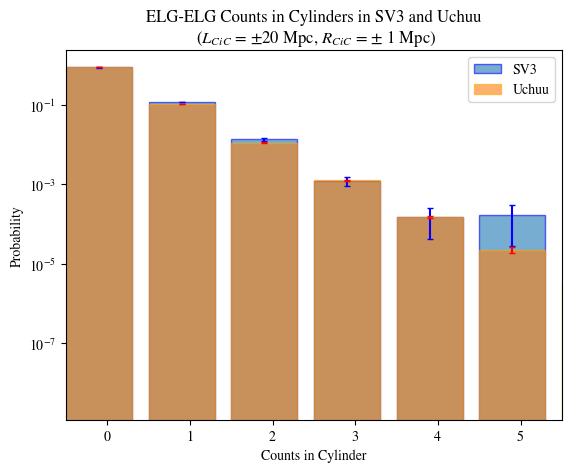

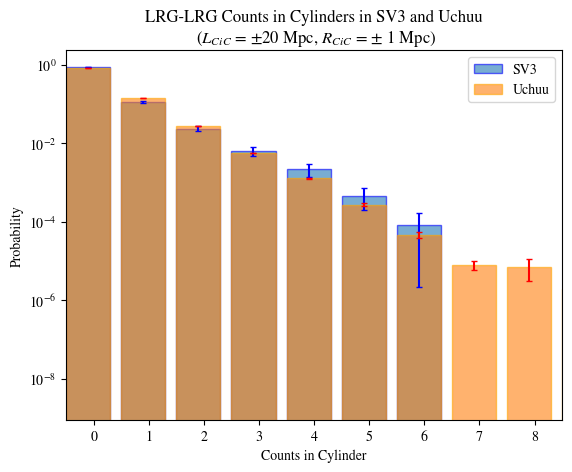

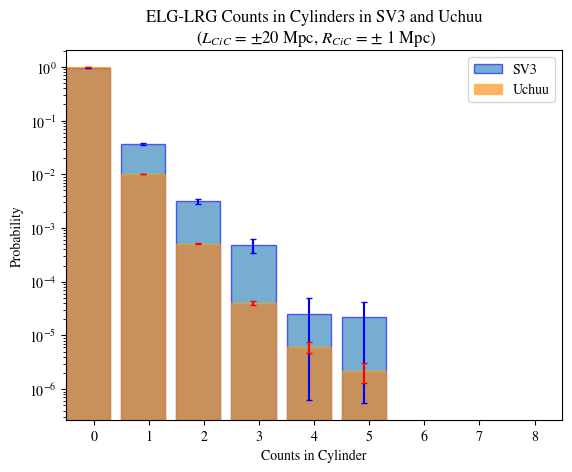

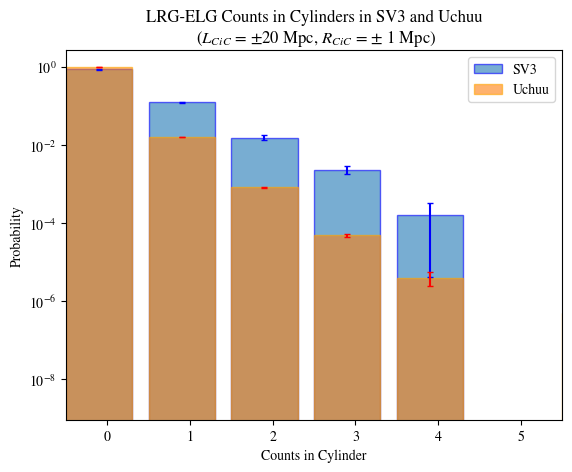

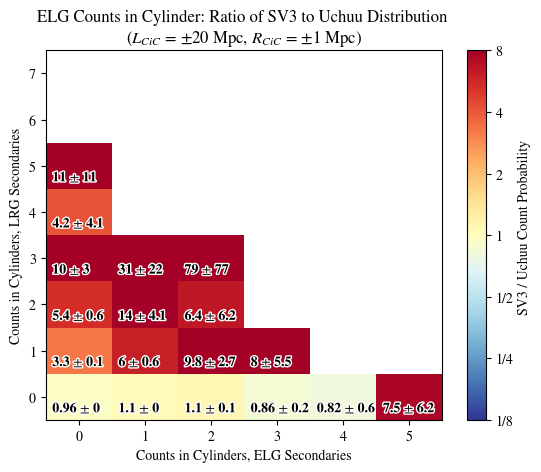

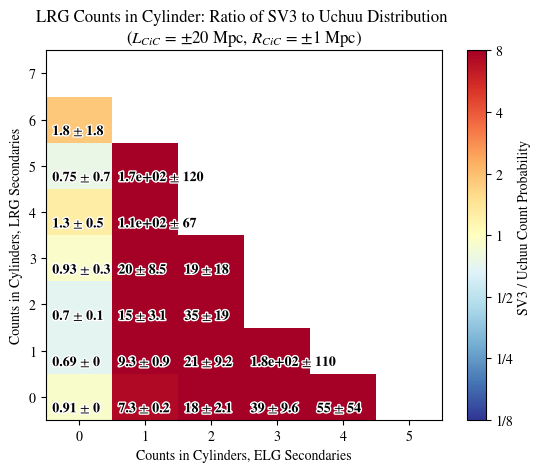

In [ ]:
catalog1 = [sv3elgnotqso_ros88,sv3lrgnotqso_ros88]
catalog2 = [uchuu_elg,uchuu_lrg]
name1 = "SV3"
name2 = "Uchuu"
binmax = 24
figdir = "Test/"
figtag = "test"
compare2CatalogsCiC(catalog1, catalog2, name1, name2, binmax, figdir, figtag)